In [1]:
import sys, os
project_root = r"C:/Users/Asia/Desktop/mocadr/MoviesRecommendations"
sys.path.insert(0, project_root)

from modules.train import train

rmse = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "SVD2")

Output()

KeyboardInterrupt: 

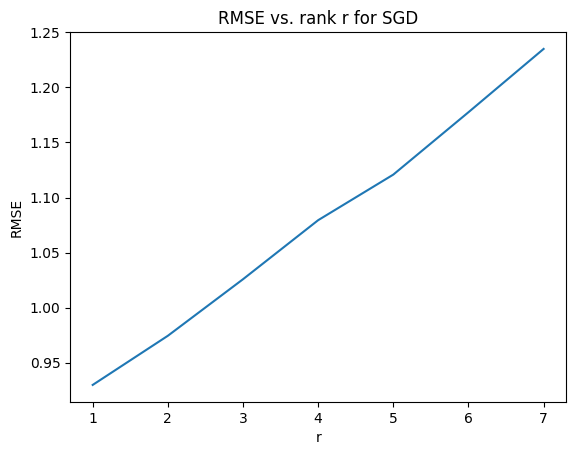

In [2]:
import matplotlib.pyplot as plt

plt.plot(rmse.keys(), rmse.values())

plt.title("RMSE vs. rank r for SGD")
plt.xlabel("r")
plt.ylabel("RMSE")

plt.show()

In [2]:
import sys, os
project_root = r"C:/Users/Asia/Desktop/mocadr/MoviesRecommendations"
sys.path.insert(0, project_root)

from modules.train import train_SVD2_model
from modules.utils import build_rating_matrix
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv")
Z, user_map, movie_map = build_rating_matrix(df, "SVD2")

W, H = train_SVD2_model(Z, 6, max_iter=1000)

Z_approx = np.dot(W, H)

Iter 0: inf
Iter 1: 0.03981846570968628
Iter 2: 0.0235004723072052
Iter 3: 0.016736090183258057
Iter 4: 0.012950330972671509
Iter 5: 0.010523751378059387
Iter 6: 0.008836537599563599
Iter 7: 0.007596731185913086
Iter 8: 0.006647869944572449
Iter 9: 0.005898207426071167
Iter 10: 0.005290478467941284
Iter 11: 0.00478711724281311
Iter 12: 0.00436265766620636
Iter 13: 0.00399935245513916
Iter 14: 0.003684520721435547
Iter 15: 0.003408953547477722
Iter 16: 0.003165692090988159
Iter 17: 0.0029495805501937866
Iter 18: 0.0027563869953155518
Iter 19: 0.002583041787147522
Iter 20: 0.0024267733097076416
Iter 21: 0.002285413444042206
Iter 22: 0.0021570920944213867
Iter 23: 0.002040296792984009
Iter 24: 0.0019336715340614319
Iter 25: 0.0018360018730163574
Iter 26: 0.0017462894320487976
Iter 27: 0.0016637668013572693
Iter 28: 0.0015875697135925293
Iter 29: 0.0015170872211456299
Iter 30: 0.001451641321182251
Iter 31: 0.0013908371329307556
Iter 32: 0.0013341978192329407
Iter 33: 0.0012812986969947815


KeyboardInterrupt: 

In [7]:
from modules.predict import predict

pred_df = predict("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv", {
            "Z_approx": Z_approx,
            "user_map": user_map,
            "movie_map": movie_map
        })

print(pred_df)

    userId  movieId  rating
0      432    77866     3.0
1      288      474     3.5
2      599     4351     2.5
3       42     2987     4.0
4       75     1610     3.5
..     ...      ...     ...
95     279   164179     3.5
96     428     6365     2.5
97     152      858     4.5
98     328     1198     3.5
99     427      435     2.5

[100 rows x 3 columns]


In [10]:
from sklearn.metrics import mean_squared_error

df_pred = pred_df
df_true = pd.read_csv("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test_with_ratings.csv")

# Compute RMSE using scikit-learn's mean_squared_error function
mse = mean_squared_error(df_true["rating"], df_pred["rating"])
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.4f}")

RMSE: 0.7969
